# Read HELD BCC force constants

Read and inspect the force constants generated under `ForceConstants/results`. The master index contains one row per non-magnetic Fe BCC dataset. Each detailed NPZ contains the 14 Born–von Kármán elements for every retained MD step, plus the complete HELD coefficients and tensors.

The 14 stored labels are `alpha_0`, `alpha_1`, `beta_1`, `alpha_2`, `beta_2`, `alpha_3`, `beta_3`, `gamma_3`, `alpha_4`, `beta_4`, `gamma_4`, `delta_4`, `alpha_5`, and `beta_5`. `alpha_0` is onsite and is derived through the acoustic sum rule; the remaining 13 are independent.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
FC_DIR = CWD if (CWD / 'read_FC.ipynb').is_file() else CWD / 'ForceConstants'
if not FC_DIR.is_dir():
    raise FileNotFoundError('Run from IronCoreMD/ForceConstants or the IronCoreMD root')
RESULTS_DIR = FC_DIR / 'results'
INDEX_NPZ = RESULTS_DIR / 'bcc_held_5nn_index.npz'
if not INDEX_NPZ.is_file():
    raise FileNotFoundError(f'Missing master index: {INDEX_NPZ}')
print('Results:', RESULTS_DIR)
print('Master index:', INDEX_NPZ)

Results: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/results
Master index: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/results/bcc_held_5nn_index.npz


## 1. Read the master index

This table provides the mean of every force constant for each trajectory. Failed cases remain visible with their error message.

In [2]:
with np.load(INDEX_NPZ, allow_pickle=False) as index:
    schema = index['schema_version'].item()
    fc_labels = index['fc_labels'].astype(str)
    fc_units = index['fc_units'].item()
    index_table = pd.DataFrame({
        'case_id': index['case_id'].astype(str),
        'status': index['status'].astype(str),
        'n_frames': index['n_frames'],
        'natoms': index['natoms'],
        'source_path': index['source_path'].astype(str),
        'output_path': index['output_path'].astype(str),
        'error': index['error'].astype(str),
        **{label: index['fc_mean'][:, column] for column, label in enumerate(fc_labels)},
    })

def lattice_temperature(path):
    match = re.search(r'(\d+\.\d+)_([0-9]+)K', Path(path).name)
    return (float(match.group(1)), int(match.group(2))) if match else (np.nan, np.nan)

parsed = [lattice_temperature(path) for path in index_table.source_path]
index_table.insert(1, 'lattice_a_A', [value[0] for value in parsed])
index_table.insert(2, 'temperature_K', [value[1] for value in parsed])
print('Schema:', schema)
print('Units:', fc_units)
print('Status counts:', index_table.status.value_counts().to_dict())
display(index_table)

Schema: held-bcc-5nn-bvk14-index-v2
Units: eV/angstrom^2
Status counts: {'completed': 137, 'failed': 1}


,case_id,lattice_a_A,temperature_K,status,n_frames,natoms,source_path,output_path,error,alpha_0,...,beta_2,alpha_3,beta_3,gamma_3,alpha_4,beta_4,gamma_4,delta_4,alpha_5,beta_5
0,2_29_4000K__43ee4c4f,2.29,4000.0,completed,399,128,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,,47.234569,...,0.963980,-0.408366,0.424752,-0.459035,-0.792778,0.135793,0.059252,0.396112,-0.374962,-0.617593
1,2_29_4500K__ed36d84b,2.29,4500.0,completed,399,128,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,,46.390022,...,1.076894,-0.447009,-0.031747,-0.538812,-0.515098,0.111071,0.083949,0.231798,-0.249860,-0.455447
2,2_29_5000K__e8b3ab4b,2.29,5000.0,completed,399,128,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,,46.066560,...,0.508757,-0.447800,0.217477,-0.553989,-0.855490,0.047517,0.082515,0.177492,0.033659,-0.526690
3,2_29_5500K__433f7228,2.29,5500.0,completed,399,128,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,,45.988021,...,0.870699,-0.385962,-0.043647,-0.574281,-0.520961,0.103686,0.062557,0.253007,-0.214660,-0.492502
4,2_29_6000K__56191404,2.29,6000.0,completed,399,128,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,,46.394093,...,1.084347,-0.231174,0.132619,-0.557044,-0.686045,-0.005594,0.032933,0.123972,-0.015252,-0.433490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,2_55_4000K__3b01b60f,2.55,4000.0,completed,399,128,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,,17.417398,...,0.493079,-0.103547,-0.121677,-0.179851,-0.183074,0.009734,-0.017037,-0.029915,-0.117735,-0.176789
134,2_55_4500K__f2bb4b5e,2.55,4500.0,completed,399,128,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,,12.896140,...,0.796572,-0.140996,-0.259890,-0.262340,-0.180281,-0.025808,-0.022634,-0.058323,0.009842,-0.161101
135,2_55_5000K__49ac84d1,2.55,5000.0,completed,399,128,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,,9.171561,...,0.645213,0.046483,-0.111365,-0.240374,-0.237977,-0.026934,-0.045668,-0.034241,-0.039726,-0.038941
136,2_55_5500K__4a3c421d,2.55,5500.0,completed,162,128,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,,13.681237,...,0.521578,0.084360,-0.297724,-0.302000,-0.133028,0.019766,-0.032280,0.010798,-0.144013,-0.130063


In [3]:
failed = index_table[index_table.status == 'failed'][
    ['case_id', 'source_path', 'error']
]
if len(failed):
    display(failed)
else:
    print('No failed cases.')

,case_id,source_path,error
57,2_40_5000K_disp__7e1101ee,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,ValueError: Could not map supercell atom at pr...


## 2. Select one trajectory

Set `SELECT_CASE_ID` to a value from the master table. Leaving it as `None` selects the first completed case. The path fallback makes the notebook portable if the repository is moved.

In [4]:
SELECT_CASE_ID = None  # Example: '2_40_5000K__f97da147'

completed = index_table[index_table.status.isin(['completed', 'cached'])].copy()
if completed.empty:
    raise RuntimeError('The master index contains no completed cases')
if SELECT_CASE_ID is None:
    selected_row = completed.iloc[0]
else:
    matches = completed[completed.case_id == SELECT_CASE_ID]
    if len(matches) != 1:
        raise KeyError(f'Expected one completed case named {SELECT_CASE_ID!r}; found {len(matches)}')
    selected_row = matches.iloc[0]

CASE_NPZ = Path(selected_row.output_path)
if not CASE_NPZ.is_file():
    CASE_NPZ = RESULTS_DIR / CASE_NPZ.name
if not CASE_NPZ.is_file():
    raise FileNotFoundError(CASE_NPZ)
print('Selected case:', selected_row.case_id)
print('Source:', selected_row.source_path)
print('Result:', CASE_NPZ)

Selected case: 2_29_4000K__43ee4c4f
Source: /Users/dajuarez4/Documents/Fe/IronCoreMD/dataset/bcc/non-mag/2.29_4000K.npz
Result: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/results/2_29_4000K__43ee4c4f_held_5nn.npz


## 3. Read all 14 constants by MD step

In [5]:
with np.load(CASE_NPZ, allow_pickle=False) as result:
    required = {'step_ids', 'frame_indices', 'fc_labels', 'fc_per_md_step', 'fc_mean', 'fc_units'}
    missing = required.difference(result.files)
    if missing:
        raise KeyError(f'Result uses an incompatible schema; missing {sorted(missing)}')
    case_schema = result['schema_version'].item()
    step_ids = result['step_ids'].astype(int)
    frame_indices = result['frame_indices'].astype(int)
    labels = result['fc_labels'].astype(str)
    values = result['fc_per_md_step'].astype(float)
    means = result['fc_mean'].astype(float)
    units = result['fc_units'].item()
    shell_distances = result['shell_distances_ang'].astype(float)

if values.shape != (len(step_ids), 14):
    raise ValueError(f'Expected (n_steps, 14), found {values.shape}')
step_table = pd.DataFrame(values, columns=labels)
step_table.insert(0, 'frame_index', frame_indices)
step_table.insert(0, 'md_step', step_ids)
mean_table = pd.DataFrame({'FC': labels, 'mean': means, 'units': units})
print('Schema:', case_schema)
print('Number of MD steps:', len(step_table))
print('Shell distances (angstrom):', shell_distances)
display(mean_table)
display(step_table)

Schema: held-bcc-5nn-bvk14-v2
Number of MD steps: 399
Shell distances (angstrom): [1.98319814 2.28999996 3.238549   3.79753532 3.96639628]


,FC,mean,units
0,alpha_0,47.234569,eV/angstrom^2
1,alpha_1,-4.108108,eV/angstrom^2
2,beta_1,-7.593066,eV/angstrom^2
3,alpha_2,-6.410474,eV/angstrom^2
4,beta_2,0.963980,eV/angstrom^2
5,alpha_3,-0.408366,eV/angstrom^2
6,beta_3,0.424752,eV/angstrom^2
7,gamma_3,-0.459035,eV/angstrom^2
8,alpha_4,-0.792778,eV/angstrom^2
9,beta_4,0.135793,eV/angstrom^2


,md_step,frame_index,alpha_0,alpha_1,beta_1,alpha_2,beta_2,alpha_3,beta_3,gamma_3,alpha_4,beta_4,gamma_4,delta_4,alpha_5,beta_5
0,1,0,54.867644,-4.298054,-10.822664,-1.482917,0.352451,-1.006315,-0.179177,-0.809109,-0.888156,-0.355988,0.467695,-0.071602,-0.083432,-0.505828
1,2,1,54.396942,-4.428314,-10.719238,-1.640721,0.321139,-1.038601,-0.162415,-0.745485,-0.694316,-0.339619,0.492363,-0.049593,-0.066424,-0.455260
2,3,2,46.607151,-4.351740,-10.645867,-1.418268,0.531397,-0.918803,-0.035723,-0.720246,-0.471282,-0.215306,0.485627,-0.039111,0.011734,-0.444446
3,4,3,46.761258,-4.493421,-10.675140,-1.643079,0.608384,-0.915598,-0.047740,-0.687962,-0.308403,-0.205457,0.478413,-0.020540,-0.020302,-0.412657
4,5,4,46.661588,-4.586441,-10.623059,-1.843943,0.699014,-0.872066,-0.057791,-0.657701,-0.190054,-0.185630,0.461331,-0.000913,-0.079640,-0.399224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,395,394,51.770588,-4.815662,-7.776462,-8.591167,0.778761,1.096913,0.564629,-0.275132,-0.210603,0.091866,0.030153,1.080153,-0.983464,-0.907273
395,396,395,51.475718,-4.784090,-7.722408,-8.597828,0.932906,1.105603,0.512118,-0.361389,-0.211989,0.065727,0.039219,1.051963,-0.951754,-0.913123
396,397,396,51.057999,-4.752442,-7.661351,-8.574564,1.001098,1.100090,0.478438,-0.393856,-0.195142,0.043656,0.051292,1.024189,-0.907370,-0.906723
397,398,397,50.532818,-4.658041,-7.597719,-8.563309,1.055259,1.082936,0.443595,-0.445034,-0.208048,0.038122,0.046648,0.995212,-0.898624,-0.905017


## 4. Select one MD step

Use the printed QE/MD step ID, not the row number.

In [6]:
SELECT_MD_STEP = int(step_ids[0])
selected_step = step_table[step_table.md_step == SELECT_MD_STEP]
if selected_step.empty:
    raise KeyError(f'MD step {SELECT_MD_STEP} is not stored in this result')
display(selected_step.set_index('md_step').T.rename(columns={SELECT_MD_STEP: 'value'}))

md_step,value
frame_index,0.000000
alpha_0,54.867644
alpha_1,-4.298054
beta_1,-10.822664
alpha_2,-1.482917
beta_2,0.352451
alpha_3,-1.006315
beta_3,-0.179177
gamma_3,-0.809109
alpha_4,-0.888156


## 5. Plot force constants over the trajectory

Change `PLOT_LABELS` to display a subset.

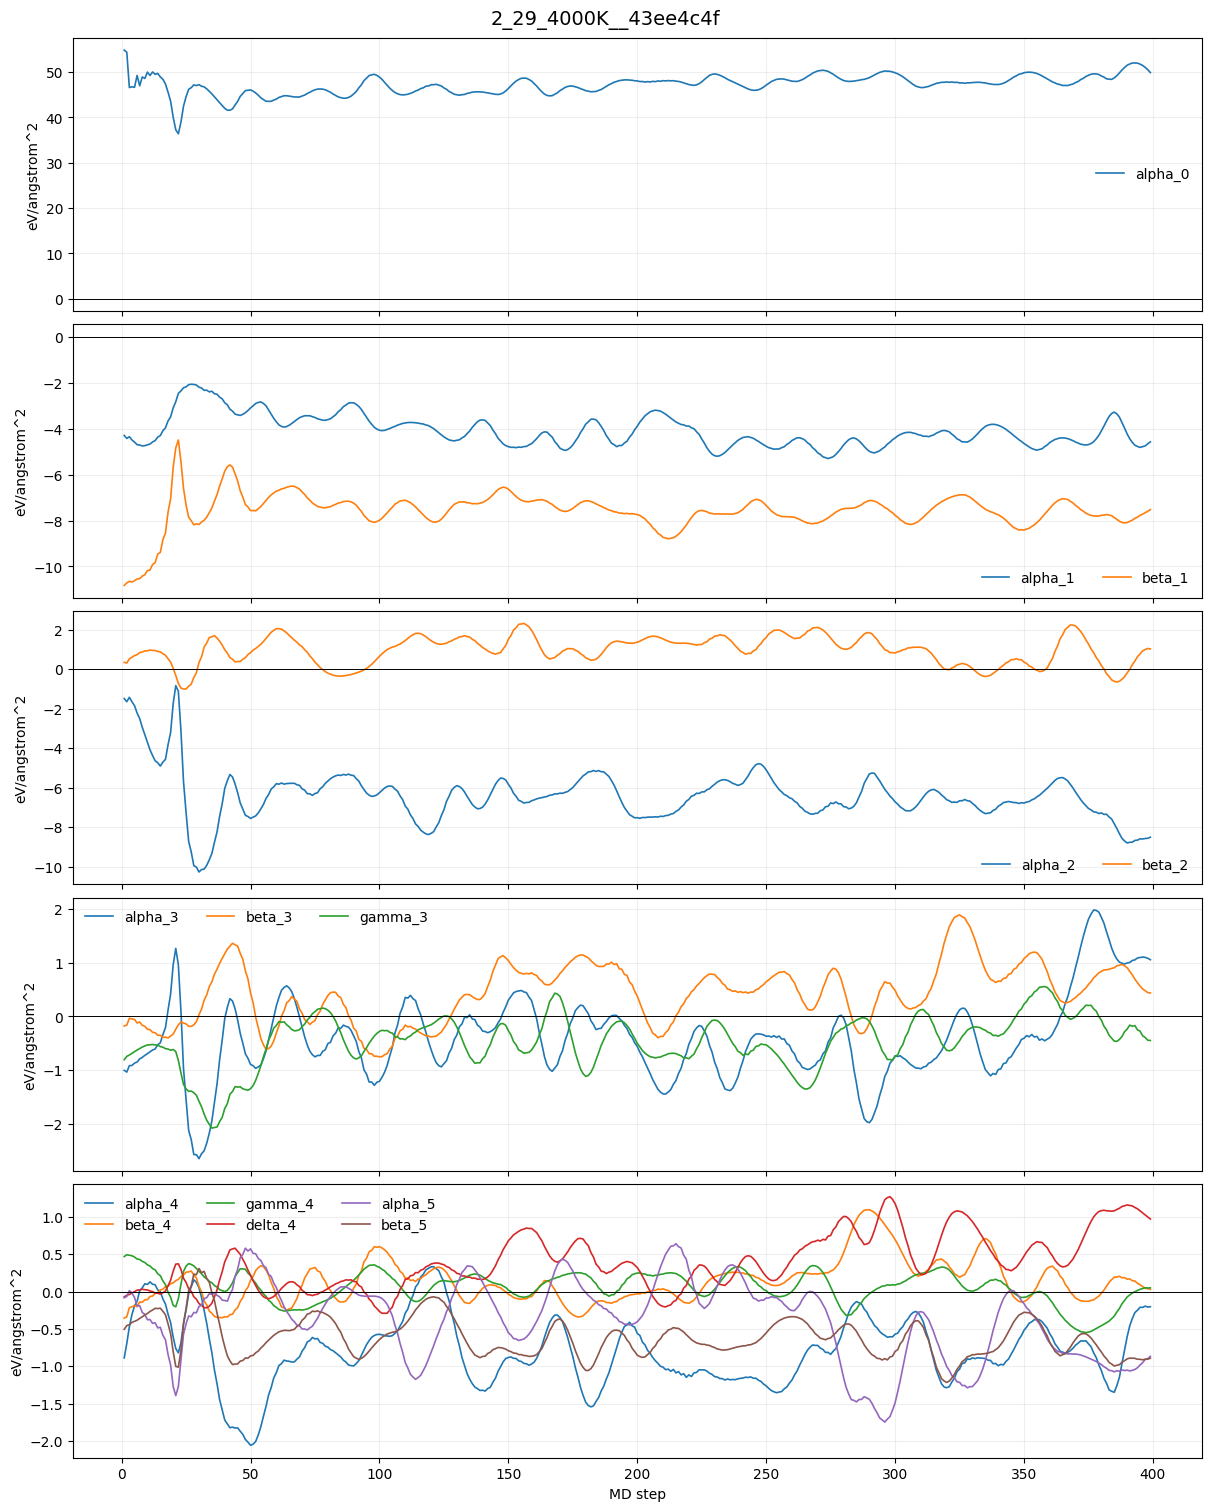

In [7]:
PLOT_LABELS = labels.tolist()
unknown = sorted(set(PLOT_LABELS).difference(labels))
if unknown:
    raise KeyError(f'Unknown FC labels: {unknown}')

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True, constrained_layout=True)
groups = [
    ['alpha_0'],
    ['alpha_1', 'beta_1'],
    ['alpha_2', 'beta_2'],
    ['alpha_3', 'beta_3', 'gamma_3'],
    ['alpha_4', 'beta_4', 'gamma_4', 'delta_4', 'alpha_5', 'beta_5'],
]
for axis, group in zip(axes, groups):
    for label in group:
        if label in PLOT_LABELS:
            axis.plot(step_ids, step_table[label], linewidth=1.2, label=label)
    axis.axhline(0.0, color='black', linewidth=0.7)
    axis.set_ylabel(units)
    axis.grid(alpha=0.2)
    axis.legend(frameon=False, ncol=3)
axes[-1].set_xlabel('MD step')
fig.suptitle(str(selected_row.case_id), fontsize=14)
plt.show()

## 6. Read the complete HELD tensors for one step

The BvK table is convenient for analysis. These arrays expose the complete tensor representation when needed.

In [8]:
step_position = int(np.flatnonzero(step_ids == SELECT_MD_STEP)[0])
with np.load(CASE_NPZ, allow_pickle=False) as result:
    held_basis_labels = result['held_basis_labels'].astype(str)
    held_coefficients = result['held_coefficients_per_frame'][step_position]
    offsite_fc = result['offsite_fc_per_frame'][step_position]
    onsite_fc = result['onsite_fc_per_frame'][step_position]
    pair_keys = result['offsite_pair_keys']
    shell_ids = result['offsite_shell_id']
print('HELD independent coefficients:', held_coefficients.shape)
print('Offsite FC tensors:', offsite_fc.shape)
print('Onsite FC tensors:', onsite_fc.shape)
display(pd.DataFrame({'basis': held_basis_labels, 'value': held_coefficients, 'units': units}))

HELD independent coefficients: (13,)
Offsite FC tensors: (58, 3, 3)
Onsite FC tensors: (1, 3, 3)


,basis,value,units
0,b000,75.452453,eV/angstrom^2
1,b001,-3.510682,eV/angstrom^2
2,b002,-1.220928,eV/angstrom^2
3,b003,4.838209,eV/angstrom^2
4,b004,3.485979,eV/angstrom^2
5,b005,-2.263796,eV/angstrom^2
6,b006,-2.466356,eV/angstrom^2
7,b007,-3.985695,eV/angstrom^2
8,b008,-3.412283,eV/angstrom^2
9,b009,-0.351471,eV/angstrom^2


## 7. Optional CSV exports

In [9]:
EXPORT_CSV = False
if EXPORT_CSV:
    export_dir = FC_DIR / 'exports'
    export_dir.mkdir(parents=True, exist_ok=True)
    step_csv = export_dir / f'{selected_row.case_id}_FC_by_md_step.csv'
    mean_csv = export_dir / f'{selected_row.case_id}_FC_mean.csv'
    step_table.to_csv(step_csv, index=False)
    mean_table.to_csv(mean_csv, index=False)
    print('Wrote:', step_csv)
    print('Wrote:', mean_csv)
else:
    print('Set EXPORT_CSV=True to export the selected case.')

Set EXPORT_CSV=True to export the selected case.
